In [3]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Display settings ───────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlepad"] = 12

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [4]:
# ── Load dataset ───────────────────────────────────────────────────────────
df = pd.read_excel("C:\\Users\\savin\\Downloads\\bank-marketing-analysis\\data\\bank_marketing.xlsx")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape: 41,188 rows × 21 columns

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

First 3 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191,no


In [5]:
# ── Data quality audit ─────────────────────────────────────────────────────
print("=" * 50)
print("DATA TYPES & NULL CHECK")
print("=" * 50)
audit = pd.DataFrame({
    "dtype"     : df.dtypes,
    "nulls"     : df.isnull().sum(),
    "null_%"    : (df.isnull().sum() / len(df) * 100).round(2),
    "unique_val": df.nunique()
})
print(audit)

print(f"\nDuplicate rows: {df.duplicated().sum()}")

DATA TYPES & NULL CHECK
                  dtype  nulls  null_%  unique_val
age               int64      0    0.00          78
job              object      0    0.00          12
marital          object      0    0.00           4
education        object      0    0.00           8
default          object      0    0.00           3
housing          object      0    0.00           3
loan             object      0    0.00           3
contact          object      0    0.00           2
month            object      0    0.00          10
day_of_week      object      0    0.00           5
duration          int64      0    0.00        1544
campaign          int64      0    0.00          42
pdays             int64      0    0.00          27
previous          int64      0    0.00           8
poutcome         object      0    0.00           3
emp.var.rate    float64      0    0.00          10
cons.price.idx  float64      0    0.00          26
cons.conf.idx   float64      0    0.00          26
euribor

In [6]:
# ── 1. Remove duplicates ───────────────────────────────────────────────────
df = df.drop_duplicates()

# ── 2. Rename target column for clarity ───────────────────────────────────
df = df.rename(columns={"y": "subscribed"})

# ── 3. Replace 'unknown' with NaN for honest analysis ─────────────────────
df = df.replace("unknown", np.nan)

# ── 4. Age groups ──────────────────────────────────────────────────────────
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18–30", "31–40", "41–50", "51–60", "60+"]
)

# ── 5. Call duration in minutes (easier to interpret than seconds) ─────────
df["duration_min"] = (df["duration"] / 60).round(2)

# ── 6. Was the customer previously contacted? ──────────────────────────────
# pdays = 999 means never contacted before — make this explicit
df["prev_contacted"] = df["pdays"].apply(
    lambda x: "No" if x == 999 else "Yes"
)

# ── 7. Binary target for numeric operations ────────────────────────────────
df["subscribed_num"] = (df["subscribed"] == "yes").astype(int)

# ── 8. Month ordering (chronological, not alphabetical) ───────────────────
month_order = ["mar","apr","may","jun","jul","aug",
               "sep","oct","nov","dec"]
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

# ── Confirm ────────────────────────────────────────────────────────────────
print(f"✓ Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNew columns added: age_group, duration_min, prev_contacted, subscribed_num")
print(f"\nSubscription breakdown:")
print(df["subscribed"].value_counts())
print(f"\nOverall conversion rate: {df['subscribed_num'].mean()*100:.1f}%")

✓ Cleaned dataset: 41,176 rows × 25 columns

New columns added: age_group, duration_min, prev_contacted, subscribed_num

Subscription breakdown:
subscribed
no     36537
yes     4639
Name: count, dtype: int64

Overall conversion rate: 11.3%


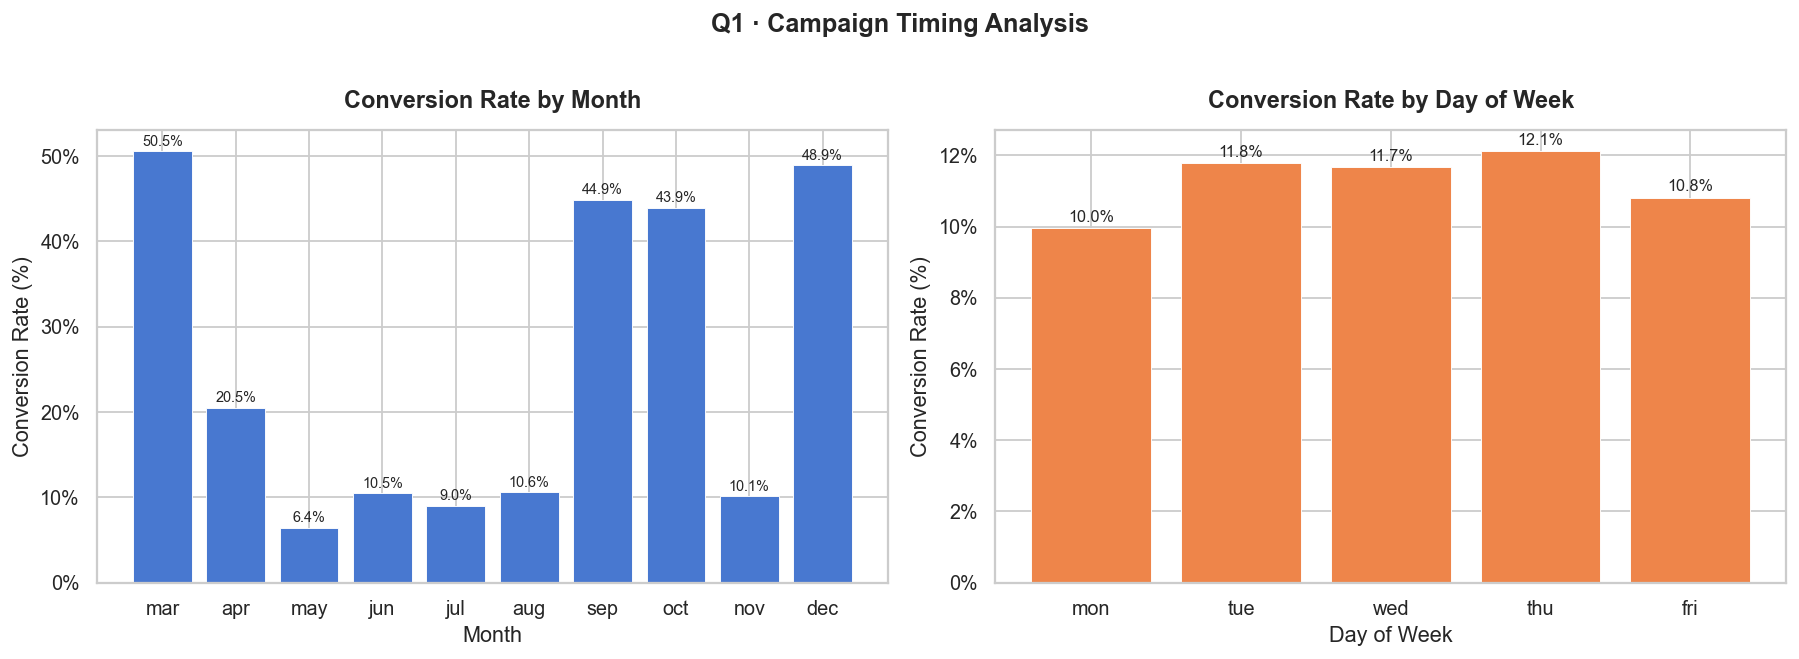

✓ Saved: chart1_2_timing_analysis.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q1 · Campaign Timing Analysis", fontsize=14, fontweight="bold", y=1.01)

# ── Chart 1: Conversion rate by month ─────────────────────────────────────
monthly = (df.groupby("month", observed=True)["subscribed_num"]
             .agg(["mean", "count"])
             .reset_index())
monthly.columns = ["month", "conv_rate", "contacts"]
monthly["conv_rate_pct"] = monthly["conv_rate"] * 100

ax1 = axes[0]
bars = ax1.bar(monthly["month"], monthly["conv_rate_pct"],
               color=sns.color_palette("muted")[0], edgecolor="white", linewidth=0.5)
ax1.set_xlabel("Month")
ax1.set_ylabel("Conversion Rate (%)")
ax1.set_title("Conversion Rate by Month")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, monthly["conv_rate_pct"]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

# ── Chart 2: Conversion rate by day of week ────────────────────────────────
day_order = ["mon", "tue", "wed", "thu", "fri"]
daily = (df.groupby("day_of_week")["subscribed_num"]
           .mean()
           .reindex(day_order)
           .reset_index())
daily.columns = ["day", "conv_rate"]
daily["conv_rate_pct"] = daily["conv_rate"] * 100

ax2 = axes[1]
bars2 = ax2.bar(daily["day"], daily["conv_rate_pct"],
                color=sns.color_palette("muted")[1], edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Conversion Rate (%)")
ax2.set_title("Conversion Rate by Day of Week")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars2, daily["conv_rate_pct"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("C:/Users/savin/Downloads/bank-marketing-analysis/reports/chart1_2_timing_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: chart1_2_timing_analysis.png")

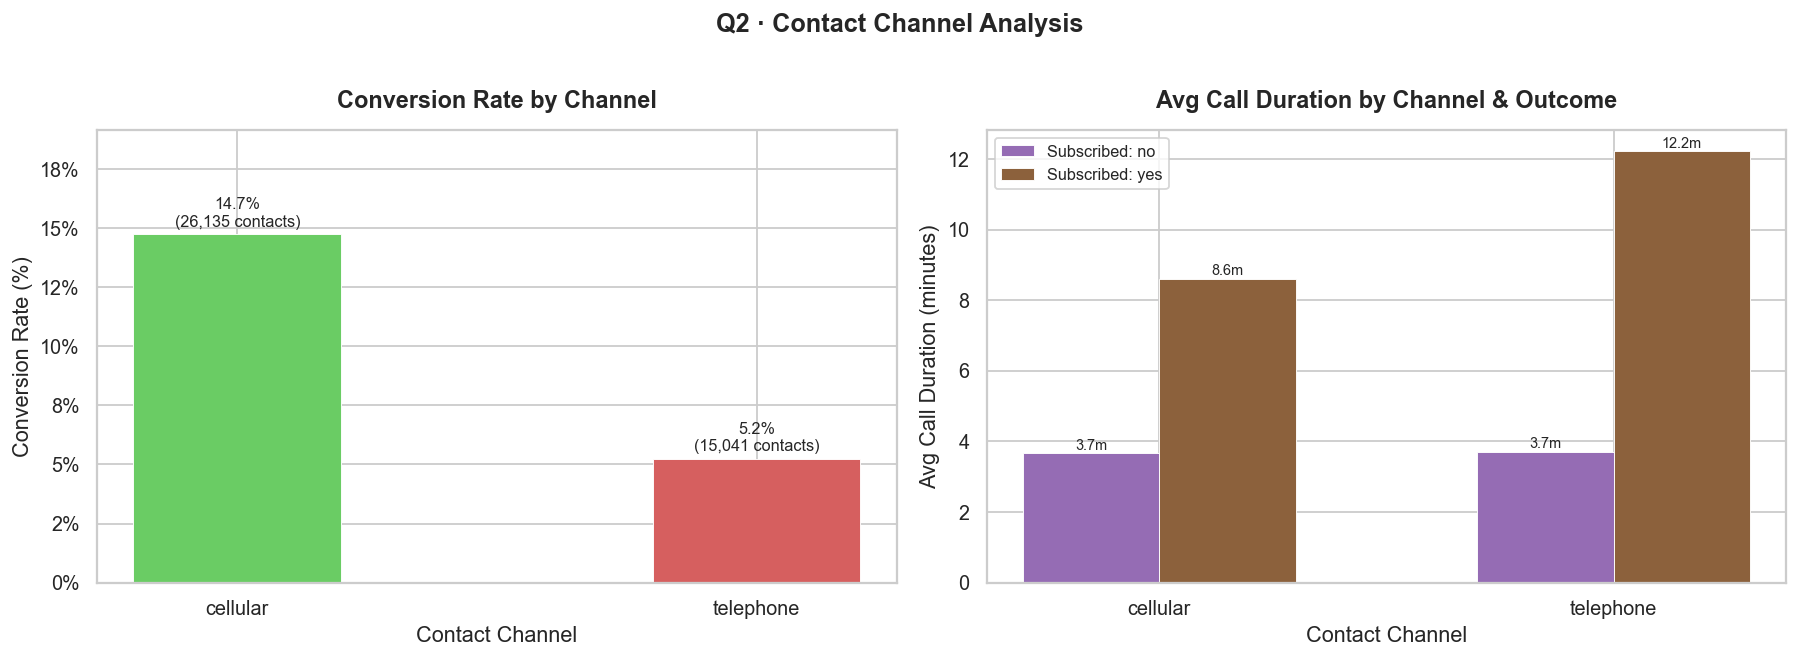

✓ Saved: chart3_4_channel_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q2 · Contact Channel Analysis", fontsize=14, fontweight="bold", y=1.01)

# ── Chart 3: Conversion rate by contact channel ────────────────────────────
channel = (df.groupby("contact")["subscribed_num"]
             .agg(["mean", "count"])
             .reset_index())
channel.columns = ["channel", "conv_rate", "contacts"]
channel["conv_rate_pct"] = channel["conv_rate"] * 100

ax1 = axes[0]
palette = [sns.color_palette("muted")[2], sns.color_palette("muted")[3]]
bars = ax1.bar(channel["channel"], channel["conv_rate_pct"],
               color=palette, edgecolor="white", linewidth=0.5, width=0.4)
ax1.set_xlabel("Contact Channel")
ax1.set_ylabel("Conversion Rate (%)")
ax1.set_title("Conversion Rate by Channel")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, (_, row) in zip(bars, channel.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{row['conv_rate_pct']:.1f}%\n({row['contacts']:,} contacts)",
             ha="center", va="bottom", fontsize=9)
ax1.set_ylim(0, channel["conv_rate_pct"].max() * 1.3)

# ── Chart 4: Avg call duration by channel and outcome ─────────────────────
duration_data = df.groupby(["contact", "subscribed"])["duration_min"].mean().reset_index()
duration_data.columns = ["channel", "subscribed", "avg_duration_min"]

ax2 = axes[1]
channels = duration_data["channel"].unique()
x = np.arange(len(channels))
width = 0.3
outcomes = ["no", "yes"]
colors = [sns.color_palette("muted")[4], sns.color_palette("muted")[5]]

for i, (outcome, color) in enumerate(zip(outcomes, colors)):
    vals = duration_data[duration_data["subscribed"] == outcome]["avg_duration_min"]
    bars2 = ax2.bar(x + i*width, vals, width, label=f"Subscribed: {outcome}",
                    color=color, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars2, vals):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{val:.1f}m", ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x + width/2)
ax2.set_xticklabels(channels)
ax2.set_xlabel("Contact Channel")
ax2.set_ylabel("Avg Call Duration (minutes)")
ax2.set_title("Avg Call Duration by Channel & Outcome")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("C:/Users/savin/Downloads/bank-marketing-analysis/reports/chart3_4_channel_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: chart3_4_channel_analysis.png")

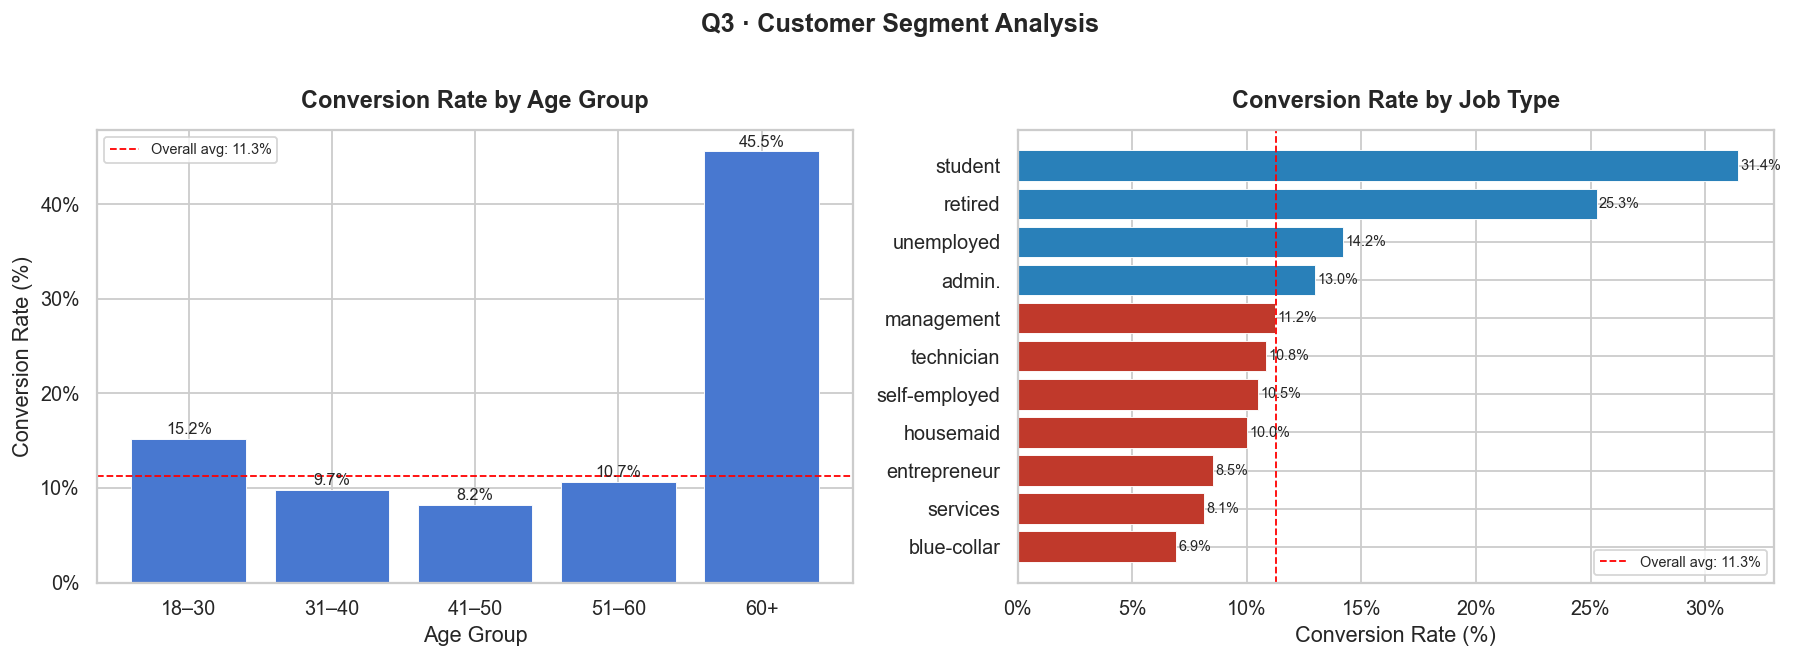

✓ Saved: chart5_6_segment_analysis.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q3 · Customer Segment Analysis", fontsize=14, fontweight="bold", y=1.01)

# ── Chart 5: Conversion rate by age group ─────────────────────────────────
age_conv = (df.groupby("age_group", observed=True)["subscribed_num"]
              .agg(["mean", "count"])
              .reset_index())
age_conv.columns = ["age_group", "conv_rate", "contacts"]
age_conv["conv_rate_pct"] = age_conv["conv_rate"] * 100

ax1 = axes[0]
bars = ax1.bar(age_conv["age_group"], age_conv["conv_rate_pct"],
               color=sns.color_palette("muted")[0], edgecolor="white", linewidth=0.5)
ax1.axhline(y=df["subscribed_num"].mean()*100, color="red",
            linestyle="--", linewidth=1, label=f"Overall avg: {df['subscribed_num'].mean()*100:.1f}%")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Conversion Rate (%)")
ax1.set_title("Conversion Rate by Age Group")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.legend(fontsize=8)
for bar, val in zip(bars, age_conv["conv_rate_pct"]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

# ── Chart 6: Conversion rate by job type ──────────────────────────────────
job_conv = (df.groupby("job")["subscribed_num"]
              .mean()
              .reset_index()
              .sort_values("subscribed_num", ascending=True))
job_conv["conv_rate_pct"] = job_conv["subscribed_num"] * 100

ax2 = axes[1]
colors_list = ["#c0392b" if v < df["subscribed_num"].mean()*100
               else "#2980b9" for v in job_conv["conv_rate_pct"]]
ax2.barh(job_conv["job"], job_conv["conv_rate_pct"],
         color=colors_list, edgecolor="white", linewidth=0.5)
ax2.axvline(x=df["subscribed_num"].mean()*100, color="red",
            linestyle="--", linewidth=1, label=f"Overall avg: {df['subscribed_num'].mean()*100:.1f}%")
ax2.set_xlabel("Conversion Rate (%)")
ax2.set_title("Conversion Rate by Job Type")
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.legend(fontsize=8)
for i, val in enumerate(job_conv["conv_rate_pct"]):
    ax2.text(val + 0.1, i, f"{val:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("C:/Users/savin/Downloads/bank-marketing-analysis/reports/chart5_6_segment_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: chart5_6_segment_analysis.png")

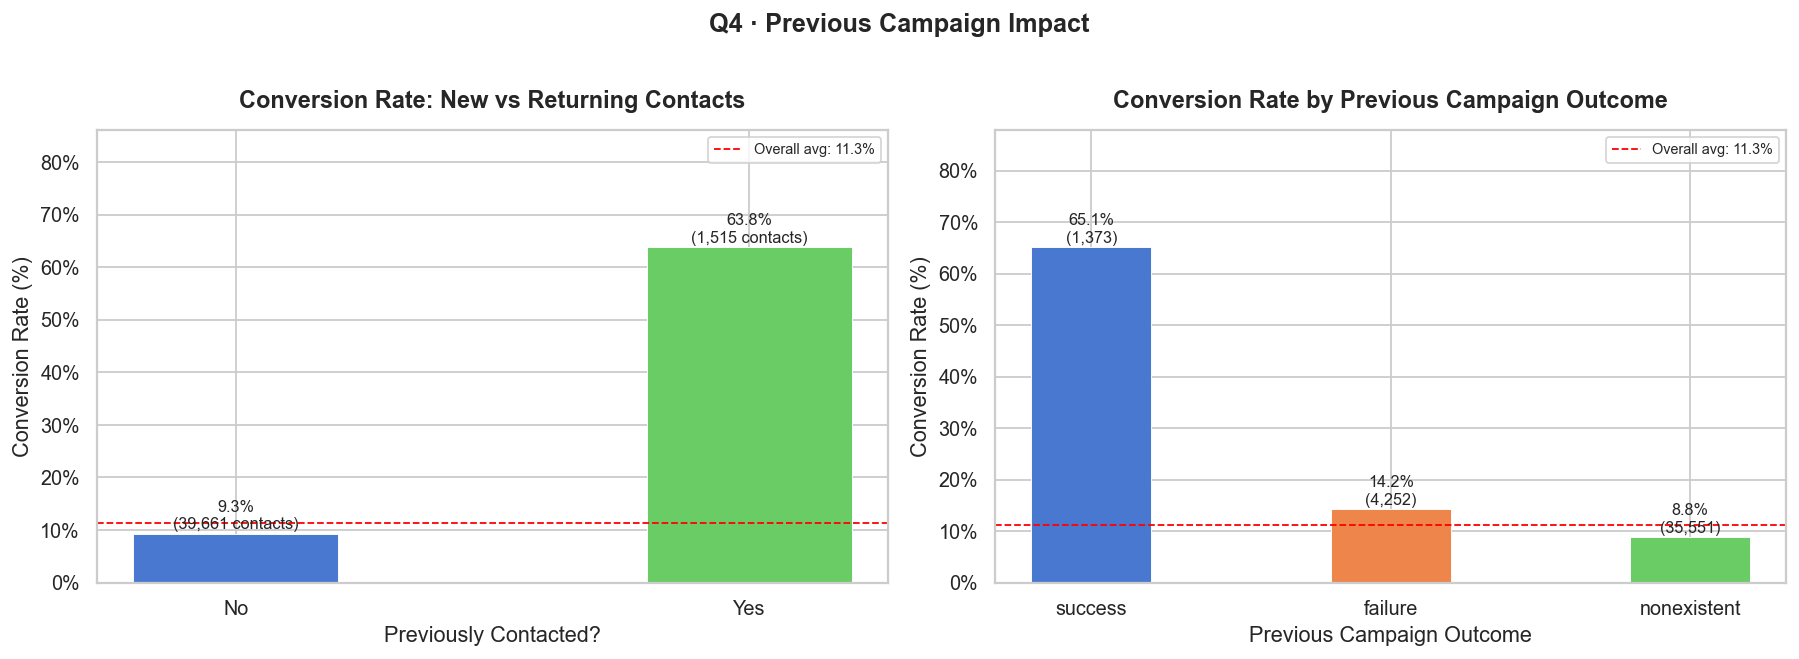

✓ Saved: chart7_previous_campaign.png


In [13]:
# ── Conversion rate: previously contacted vs not ───────────────────────────
prev_conv = (df.groupby("prev_contacted")["subscribed_num"]
               .agg(["mean", "count"])
               .reset_index())
prev_conv.columns = ["prev_contacted", "conv_rate", "contacts"]
prev_conv["conv_rate_pct"] = prev_conv["conv_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q4 · Previous Campaign Impact", fontsize=14, fontweight="bold", y=1.01)

# ── Chart 7a: Conversion rate comparison ──────────────────────────────────
ax1 = axes[0]
palette = [sns.color_palette("muted")[0], sns.color_palette("muted")[2]]
bars = ax1.bar(prev_conv["prev_contacted"], prev_conv["conv_rate_pct"],
               color=palette, edgecolor="white", linewidth=0.5, width=0.4)
ax1.axhline(y=df["subscribed_num"].mean()*100, color="red",
            linestyle="--", linewidth=1,
            label=f"Overall avg: {df['subscribed_num'].mean()*100:.1f}%")
ax1.set_xlabel("Previously Contacted?")
ax1.set_ylabel("Conversion Rate (%)")
ax1.set_title("Conversion Rate: New vs Returning Contacts")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.legend(fontsize=8)
for bar, (_, row) in zip(bars, prev_conv.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{row['conv_rate_pct']:.1f}%\n({row['contacts']:,} contacts)",
             ha="center", va="bottom", fontsize=9)
ax1.set_ylim(0, prev_conv["conv_rate_pct"].max() * 1.35)

# ── Chart 7b: Breakdown by previous outcome ───────────────────────────────
ax2 = axes[1]
pout_conv = (df.groupby("poutcome")["subscribed_num"]
               .agg(["mean", "count"])
               .reset_index())
pout_conv.columns = ["poutcome", "conv_rate", "contacts"]
pout_conv["conv_rate_pct"] = pout_conv["conv_rate"] * 100
pout_conv = pout_conv.dropna(subset=["poutcome"])
pout_conv = pout_conv.sort_values("conv_rate_pct", ascending=False)

bars2 = ax2.bar(pout_conv["poutcome"], pout_conv["conv_rate_pct"],
                color=sns.color_palette("muted"), edgecolor="white",
                linewidth=0.5, width=0.4)
ax2.axhline(y=df["subscribed_num"].mean()*100, color="red",
            linestyle="--", linewidth=1,
            label=f"Overall avg: {df['subscribed_num'].mean()*100:.1f}%")
ax2.set_xlabel("Previous Campaign Outcome")
ax2.set_ylabel("Conversion Rate (%)")
ax2.set_title("Conversion Rate by Previous Campaign Outcome")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.legend(fontsize=8)
for bar, (_, row) in zip(bars2, pout_conv.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{row['conv_rate_pct']:.1f}%\n({row['contacts']:,})",
             ha="center", va="bottom", fontsize=9)
ax2.set_ylim(0, pout_conv["conv_rate_pct"].max() * 1.35)

plt.tight_layout()
plt.savefig("C:/Users/savin/Downloads/bank-marketing-analysis/reports/chart7_previous_campaign.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: chart7_previous_campaign.png")

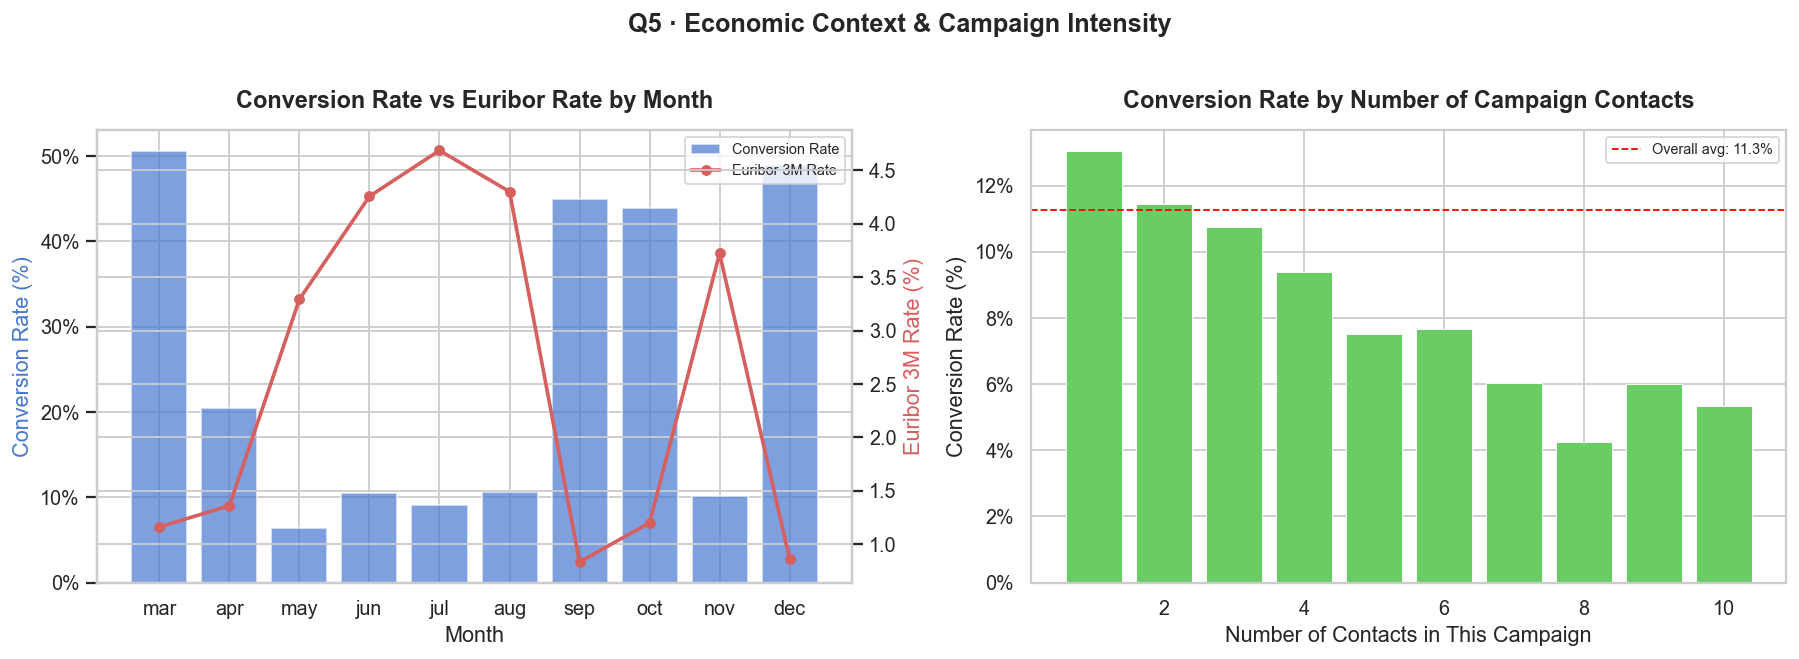

✓ Saved: chart8_economic_context.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q5 · Economic Context & Campaign Intensity",
             fontsize=14, fontweight="bold", y=1.01)

# ── Chart 8a: Conversion rate vs euribor rate by month ────────────────────
ax1 = axes[0]
monthly_eco = (df.groupby("month", observed=True)
                 .agg(conv_rate=("subscribed_num", "mean"),
                      euribor=("euribor3m", "mean"))
                 .reset_index())
monthly_eco["conv_rate_pct"] = monthly_eco["conv_rate"] * 100

color1 = sns.color_palette("muted")[0]
color2 = sns.color_palette("muted")[3]

ax1_twin = ax1.twinx()
bars = ax1.bar(monthly_eco["month"], monthly_eco["conv_rate_pct"],
               color=color1, alpha=0.7, edgecolor="white", label="Conversion Rate")
line = ax1_twin.plot(monthly_eco["month"], monthly_eco["euribor"],
                     color=color2, linewidth=2, marker="o",
                     markersize=5, label="Euribor 3M Rate")
ax1.set_xlabel("Month")
ax1.set_ylabel("Conversion Rate (%)", color=color1)
ax1_twin.set_ylabel("Euribor 3M Rate (%)", color=color2)
ax1.set_title("Conversion Rate vs Euribor Rate by Month")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

# ── Chart 8b: Conversion rate vs number of contacts made ─────────────────
ax2 = axes[1]
contact_conv = (df.groupby("campaign")["subscribed_num"]
                  .agg(["mean", "count"])
                  .reset_index())
contact_conv.columns = ["num_contacts", "conv_rate", "customers"]
contact_conv["conv_rate_pct"] = contact_conv["conv_rate"] * 100
# Only show up to 10 contacts — beyond that sample sizes are too small
contact_conv = contact_conv[contact_conv["num_contacts"] <= 10]

ax2.bar(contact_conv["num_contacts"], contact_conv["conv_rate_pct"],
        color=sns.color_palette("muted")[2], edgecolor="white", linewidth=0.5)
ax2.axhline(y=df["subscribed_num"].mean()*100, color="red",
            linestyle="--", linewidth=1,
            label=f"Overall avg: {df['subscribed_num'].mean()*100:.1f}%")
ax2.set_xlabel("Number of Contacts in This Campaign")
ax2.set_ylabel("Conversion Rate (%)")
ax2.set_title("Conversion Rate by Number of Campaign Contacts")
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("C:/Users/savin/Downloads/bank-marketing-analysis/reports/chart8_economic_context.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: chart8_economic_context.png")

In [15]:
# ── Save cleaned dataframe to CSV for SQL import ──────────────────────────
df.to_csv("C:/Users/savin/Downloads/bank-marketing-analysis/data/bank_marketing_cleaned.csv", index=False)

print(f"✓ Cleaned dataset saved to data/bank_marketing_cleaned.csv")
print(f"  Rows    : {len(df):,}")
print(f"  Columns : {df.shape[1]}")
print(f"\nColumn list for SQL table creation:")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

✓ Cleaned dataset saved to data/bank_marketing_cleaned.csv
  Rows    : 41,176
  Columns : 25

Column list for SQL table creation:
  - age: int64
  - job: object
  - marital: object
  - education: object
  - default: object
  - housing: object
  - loan: object
  - contact: object
  - month: category
  - day_of_week: object
  - duration: int64
  - campaign: int64
  - pdays: int64
  - previous: int64
  - poutcome: object
  - emp.var.rate: float64
  - cons.price.idx: float64
  - cons.conf.idx: float64
  - euribor3m: float64
  - nr.employed: int64
  - subscribed: object
  - age_group: category
  - duration_min: float64
  - prev_contacted: object
  - subscribed_num: int32
